# Official pretrained m6Anet benchmark
Same data0 validation sites. Potential pretrained training overlap prevents treating this as an independent test.

In [1]:
from pathlib import Path
import os, json
import pandas as pd
from IPython.display import display, Image
if not Path("pyproject.toml").exists():
    os.chdir(Path.cwd().parent)
summary = json.loads(Path("docs/results/m6anet_summary.json").read_text())
run = Path(summary["run_path"])

In [2]:
comparison = pd.read_csv("docs/results/comparison_with_m6anet.csv")
display(comparison[["model", "approach", "average_precision", "roc_auc", "pr_auc_trapezoid", "brier_score"]])

,model,approach,average_precision,roc_auc,pr_auc_trapezoid,brier_score
0,dummy,site_mean9,0.043511,0.500000,0.521755,0.041621
1,logistic,site_mean9,0.099416,0.707058,0.098744,0.040571
2,logistic,read9_noisy_or,0.070899,0.693366,0.070737,0.332252
3,logistic,read15_noisy_or,0.146598,0.775981,0.146083,0.294377
4,hist_boosting,site_mean9,0.394808,0.864127,0.394321,0.032065
5,hist_boosting,read9_noisy_or,0.337521,0.860411,0.336621,0.271313
6,hist_boosting,read15_noisy_or,0.379881,0.878190,0.379341,0.237489
7,random_forest,site_mean9,0.364940,0.858864,0.363981,0.033298
8,random_forest,read9_noisy_or,0.328180,0.853769,0.327293,0.284619
9,random_forest,read15_noisy_or,0.328841,0.865362,0.328197,0.253001


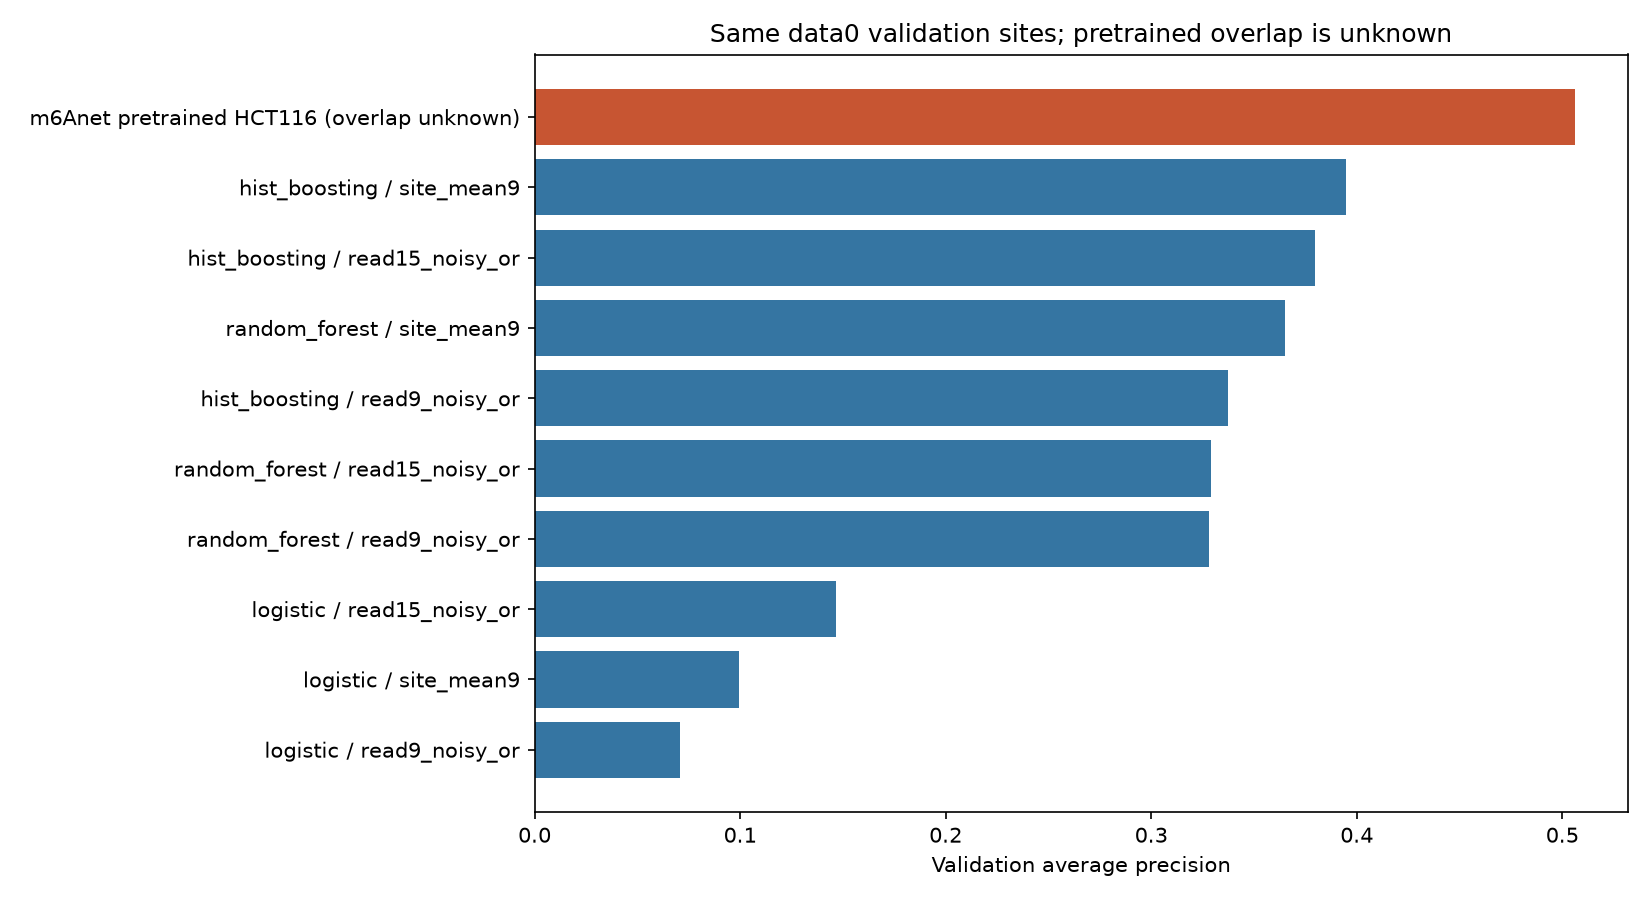

{'sites': 25350,
 'positive_sites': 1103,
 'prevalence': 0.043510848126232744,
 'average_precision': 0.5063945551069602,
 'roc_auc': 0.9346209928261353,
 'pr_auc_trapezoid': 0.505930010777156,
 'log_loss': 0.3151679735183829,
 'brier_score': 0.09248829529335484,
 'fraction_score_ge_099': 0.00611439842209073,
 'fraction_score_eq_1': 0.0,
 'unique_scores': 25342,
 'depth_score_spearman': -0.022530828160380587,
 'mean_sampling_std': None,
 'prediction_coverage': 1.0,
 'prediction_seconds': 52.73550195799908,
 'total_seconds': 74.85907016700367,
 'sampling_iterations': 1000,
 'independent_test_claim': False}

In [3]:
display(Image(filename="docs/results/comparison_with_m6anet.png"))
display(summary["metrics"])

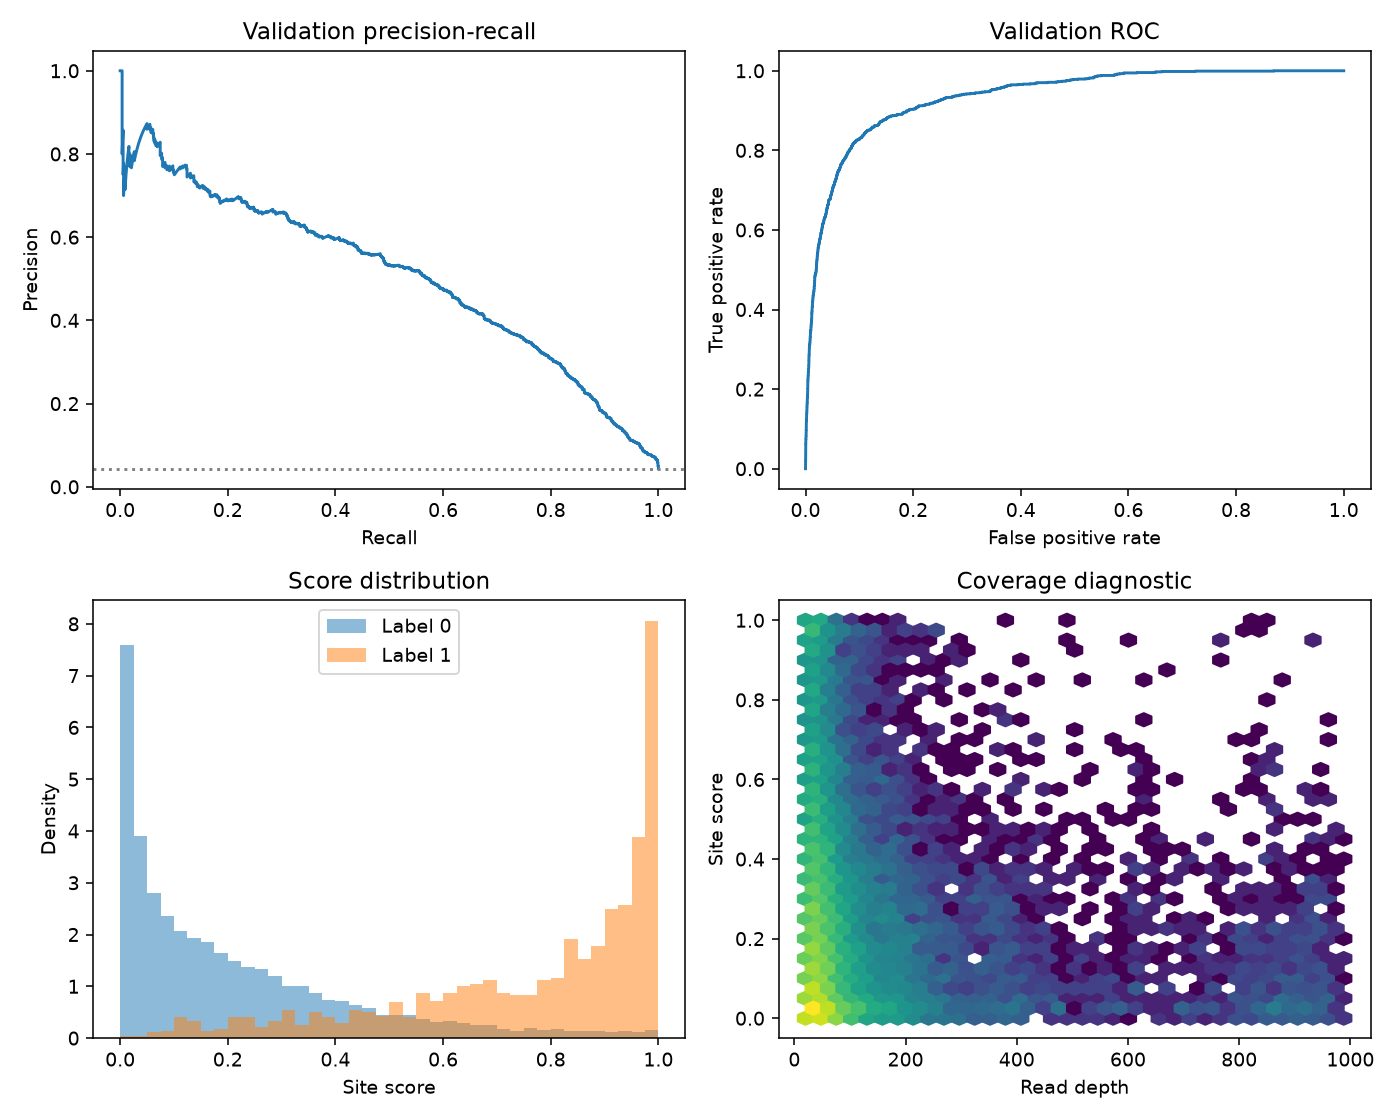

,score_bin,sites,mean_score,observed_rate
0,"(-0.001, 0.1]",10100,0.036439,0.000891
1,"(0.1, 0.2]",4582,0.147445,0.006329
2,"(0.2, 0.3]",3303,0.247736,0.011202
3,"(0.3, 0.4]",2240,0.346266,0.020982
4,"(0.4, 0.5]",1502,0.445256,0.032623
5,"(0.5, 0.6]",1011,0.546391,0.073195
6,"(0.6, 0.7]",785,0.647372,0.142675
7,"(0.7, 0.8]",503,0.750245,0.200795
8,"(0.8, 0.9]",523,0.848960,0.336520
9,"(0.9, 1.0]",801,0.959300,0.585518


In [4]:
display(Image(filename=str(run / "diagnostics.png")))
display(pd.read_csv(run / "calibration.csv"))

The checkpoint was trained on HCT116. Overlap with the course sites is unknown. m6Anet uses a learned neural embedding, pretrained normalization, and 1,000 with-replacement sampling iterations; the classical read models use fixed PCA and five without-replacement repetitions. Treat these results as a comparison of complete methods, not an isolated architecture effect.